# **Predicting County-Level Housing Prices Using Zillow Data and Apache Spark**

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark regression example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Load the dataset

In [5]:
df= spark.read.csv("/content/gdrive/My Drive/Colab Notebooks/ML 632 - Final Project/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv",header=True, inferSchema = True)
df.show(2, truncate=False) #truncate = false will show all the characters


+--------+--------+------------------+----------+---------+-----+------------------------------------+-------------+-----------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----

## Data Preprocessing

In [6]:
from pyspark.sql.functions import col

states = ["NJ", "NY", "PA", "CA", "TX"] #filtering the states
df1 = df.filter(col("State").isin(states))

#Filtering the year from 2010
date_cols = [c for c in df1.columns if "/" in c and int(c.split("/")[-1]) >= 2010]
df1 = df1.select("RegionID", "RegionName", "State", "Metro", *date_cols)
df1.show(2, truncate=False)


+--------+------------------+-----+------------------------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+------

In [7]:
#creates a row per county per month
from pyspark.sql.functions import expr, to_date

stack_expr = ", ".join([f"'{c}', `{c}`" for c in date_cols])

long_df = df1.select(
    "RegionID", "RegionName", "State", "Metro",
    expr(f"stack({len(date_cols)}, {stack_expr}) as (date_str, zhvi)")
).withColumn("date", to_date(col("date_str"), "M/d/yyyy")) \
 .drop("date_str")

In [8]:
long_df.show(5, truncate=False)
long_df.printSchema()

+--------+------------------+-----+----------------------------------+-----------+----------+
|RegionID|RegionName        |State|Metro                             |zhvi       |date      |
+--------+------------------+-----+----------------------------------+-----------+----------+
|3101    |Los Angeles County|CA   |Los Angeles-Long Beach-Anaheim, CA|373180.1624|2010-01-31|
|3101    |Los Angeles County|CA   |Los Angeles-Long Beach-Anaheim, CA|373474.9514|2010-02-28|
|3101    |Los Angeles County|CA   |Los Angeles-Long Beach-Anaheim, CA|374065.8716|2010-03-31|
|3101    |Los Angeles County|CA   |Los Angeles-Long Beach-Anaheim, CA|375749.0986|2010-04-30|
|3101    |Los Angeles County|CA   |Los Angeles-Long Beach-Anaheim, CA|378957.0933|2010-05-31|
+--------+------------------+-----+----------------------------------+-----------+----------+
only showing top 5 rows
root
 |-- RegionID: integer (nullable = true)
 |-- RegionName: string (nullable = true)
 |-- State: string (nullable = true)
 |-- 

In [9]:
long_df = long_df.dropna(subset=["zhvi", "date"])

In [10]:
print("Total rows:", long_df.count())
long_df.groupBy("State").count().orderBy("State").show()

Total rows: 78633
+-----+-----+
|State|count|
+-----+-----+
|   CA|10963|
|   NJ| 4031|
|   NY|11903|
|   PA|12549|
|   TX|39187|
+-----+-----+



## Feature Engineering

In [11]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, lead, year

w = Window.partitionBy("RegionID").orderBy("date")

# Create lag features
lag_df = long_df.withColumn("lag_1", lag("zhvi", 1).over(w))
lag_df = lag_df.withColumn("lag_3", lag("zhvi", 3).over(w))
lag_df = lag_df.withColumn("lag_12", lag("zhvi", 12).over(w))

# label = next month's price
lag_df = lag_df.withColumn("label", lead("zhvi", 1).over(w))

# year needed for train/test split
lag_df = lag_df.withColumn("year", year("date"))

In [12]:
# Drop rows where any lag or label is null
lag_df = lag_df.dropna(subset=["lag_1", "lag_3", "lag_12", "label"])

lag_df.select("RegionID", "State", "date", "zhvi", "lag_1", "lag_3", "lag_12", "label").show(5, truncate=False)

+--------+-----+----------+-----------+-----------+-----------+-----------+-----------+
|RegionID|State|date      |zhvi       |lag_1      |lag_3      |lag_12     |label      |
+--------+-----+----------+-----------+-----------+-----------+-----------+-----------+
|69      |TX   |2013-01-31|112465.2747|112428.226 |114756.9483|114250.1211|113122.2355|
|69      |TX   |2013-02-28|113122.2355|112465.2747|113432.3024|114407.1057|113704.7187|
|69      |TX   |2013-03-31|113704.7187|113122.2355|112428.226 |114241.7482|114327.9901|
|69      |TX   |2013-04-30|114327.9901|113704.7187|112465.2747|114465.0145|115007.1904|
|69      |TX   |2013-05-31|115007.1904|114327.9901|113122.2355|115309.4558|116430.2923|
+--------+-----+----------+-----------+-----------+-----------+-----------+-----------+
only showing top 5 rows


Lag features were generated using window functions, and the target variable was defined as next month’s housing price. Rows with missing lag values were removed before modeling.

## Train-Test Split

In [13]:
from pyspark.sql.functions import col

train_df=lag_df.filter(col("date") <= "2022-12-31")
test_df=lag_df.filter(col("date")>= "2023-01-01")

print("Train size:", train_df.count())
print("Test size:", test_df.count())

Train size: 57009
Test size: 15761


In [14]:
total=train_df.count()+test_df.count()
train_pct=train_df.count()/total*100
test_pct=test_df.count()/total*100

print("Train %:", round(train_pct,2))
print("Test %:", round(test_pct,2))

Train %: 78.34
Test %: 21.66


## Train baseline model

### 1. Linear Regression

In [15]:
from pyspark.ml.feature import VectorAssembler

feature_cols=['lag_1', 'lag_3', 'lag_12']
assembler=VectorAssembler(inputCols=feature_cols, outputCol="features")

In [16]:
#Linear Regression
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline

lr=LinearRegression(featuresCol="features", labelCol="label")
lr_pipeline=Pipeline(stages=[assembler, lr])
lr_model=lr_pipeline.fit(train_df)

#Predictions on test set
lr_preds=lr_model.transform(test_df)

#### Evaluate Baseline

In [17]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluate_rmse=RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName="rmse")
evaluate_mae=RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName="mae")

print("Linear Regression")
print(f"RMSE: ${evaluate_rmse.evaluate(lr_preds):,.2f}")
print(f"MAE: ${evaluate_mae.evaluate(lr_preds):,.2f}")

Linear Regression
RMSE: $3,120.14
MAE: $2,082.41


The RMSE and MAE values are close together, suggesting the model makes consistent small errors rather than occasional large mistakes.


### 2. Gradient Boosted Tree Regression

In [18]:
#Gradient Boosted Tree Regression
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    maxDepth=3,
    maxBins=32,
    minInstancesPerNode=5,
    subsamplingRate=0.8,
    maxIter=20,
    stepSize=0.05,
    seed=42
)

gbt_pipeline = Pipeline(stages=[assembler, gbt])
gbt_model = gbt_pipeline.fit(train_df)
gbt_pred = gbt_model.transform(test_df)

In [19]:
print("Gradient Boosted Trees")
print(f"RMSE: ${evaluate_rmse.evaluate(gbt_pred):,.2f}")
print(f"MAE: ${evaluate_mae.evaluate(gbt_pred):,.2f}")

Gradient Boosted Trees
RMSE: $73,152.80
MAE: $29,117.50


### 3. Random Forest

In [20]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth = 6,
    seed = 42)

rf_pipeline = Pipeline(stages=[assembler, rf])
rf_model = rf_pipeline.fit(train_df)
rf_pred = rf_model.transform(test_df)


In [21]:
print("Random Forest")
print(f"RMSE: ${evaluate_rmse.evaluate(rf_pred):,.2f}")
print(f"MAE: ${evaluate_mae.evaluate(rf_pred):,.2f}")

Random Forest
RMSE: $71,093.77
MAE: $23,697.80


## Model Evaluation

### Comparing the models


In [22]:
results = [
    ("Linear Regression", evaluate_rmse.evaluate(lr_preds), evaluate_mae.evaluate(lr_preds)),
    ("GBT Regressor", evaluate_rmse.evaluate(gbt_pred), evaluate_mae.evaluate(gbt_pred)),
    ("Random Forest", evaluate_rmse.evaluate(rf_pred), evaluate_mae.evaluate(rf_pred))
]

for model, rmse, mae in results:
    print(f"{model}: RMSE=${rmse:,.2f}, MAE=${mae:,.2f}")

Linear Regression: RMSE=$3,120.14, MAE=$2,082.41
GBT Regressor: RMSE=$73,152.80, MAE=$29,117.50
Random Forest: RMSE=$71,093.77, MAE=$23,697.80


### Example Predictions

In [23]:
lr_preds.select(
    "RegionName",
    "State",
    "date",
    "label",
    "prediction"
).orderBy("date").show(10, truncate=False)

+-----------+-----+----------+-----------+------------------+
|RegionName |State|date      |label      |prediction        |
+-----------+-----+----------+-----------+------------------+
|Cass County|TX   |2023-01-31|181350.8608|181762.18420506647|
|Frio County|TX   |2023-01-31|183780.17  |186507.9242320872 |
|Bee County |TX   |2023-01-31|187458.7284|192488.1861621626 |
|Bell County|TX   |2023-01-31|261526.2548|262713.1525840352 |
|Camp County|TX   |2023-01-31|219389.5617|217467.8969631429 |
|Elk County |PA   |2023-01-31|120261.7718|120885.36911759344|
|Lee County |TX   |2023-01-31|334124.183 |333698.3140695775 |
|Clay County|TX   |2023-01-31|197857.1001|197781.1218647251 |
|Coke County|TX   |2023-01-31|145586.125 |144592.34318957743|
|Erie County|NY   |2023-01-31|239894.9511|239963.21589956983|
+-----------+-----+----------+-----------+------------------+
only showing top 10 rows


### County Example

In [24]:
from pyspark.sql.functions import col

lr_preds.filter(col("RegionName") == "Camden County").select(
    "RegionName",
    "State",
    "date",
    "label",
    "prediction"
).orderBy("date").show(10, truncate=False)

+-------------+-----+----------+-----------+------------------+
|RegionName   |State|date      |label      |prediction        |
+-------------+-----+----------+-----------+------------------+
|Camden County|NJ   |2023-01-31|275588.4352|274500.64332140924|
|Camden County|NJ   |2023-02-28|277495.4104|275811.11047030246|
|Camden County|NJ   |2023-03-31|280412.3545|277475.26645892684|
|Camden County|NJ   |2023-04-30|284832.9601|280402.2310536576 |
|Camden County|NJ   |2023-05-31|289197.1728|284957.6133267909 |
|Camden County|NJ   |2023-06-30|292903.6861|291484.3579142516 |
|Camden County|NJ   |2023-07-31|295732.0554|297006.98672297824|
|Camden County|NJ   |2023-08-31|298240.1898|299992.74843529135|
|Camden County|NJ   |2023-09-30|300343.737 |301407.477485607  |
|Camden County|NJ   |2023-10-31|301907.745 |302812.6055526012 |
+-------------+-----+----------+-----------+------------------+
only showing top 10 rows


### Comparing prediction error by state

In [25]:
from pyspark.sql.functions import abs, avg, sqrt, col

state_error = lr_preds \
    .withColumn("abs_error", abs(col("label") - col("prediction"))) \
    .withColumn("sq_error", (col("label") - col("prediction"))**2) \
    .groupBy("State") \
    .agg(
        sqrt(avg("sq_error")).alias("RMSE"),
        avg("abs_error").alias("MAE")
    ) \
    .orderBy("RMSE")

state_error.show()

+-----+------------------+------------------+
|State|              RMSE|               MAE|
+-----+------------------+------------------+
|   PA|1720.3870846201273| 1339.537889181759|
|   NY| 2510.621179126397|  1655.40756705702|
|   NJ|2647.0149824939444|2004.1413249741388|
|   TX| 2676.408714993338|2031.6793270945916|
|   CA|  5741.49125369054| 3637.308400149704|
+-----+------------------+------------------+



### Average housing price by state

In [26]:
long_df.groupBy("State") \
    .agg(avg("zhvi").alias("avg_home_zhvi")) \
    .orderBy("avg_home_zhvi", ascending=False) \
    .show()

+-----+------------------+
|State|     avg_home_zhvi|
+-----+------------------+
|   CA|429318.57431996707|
|   NJ| 349379.6044325473|
|   NY| 234149.0891704852|
|   TX|178661.21661805446|
|   PA| 166470.0089393426|
+-----+------------------+



## Visualization

In [27]:
sample_df = lr_preds.select("label", "prediction").sample(fraction=0.01, seed=42).toPandas()

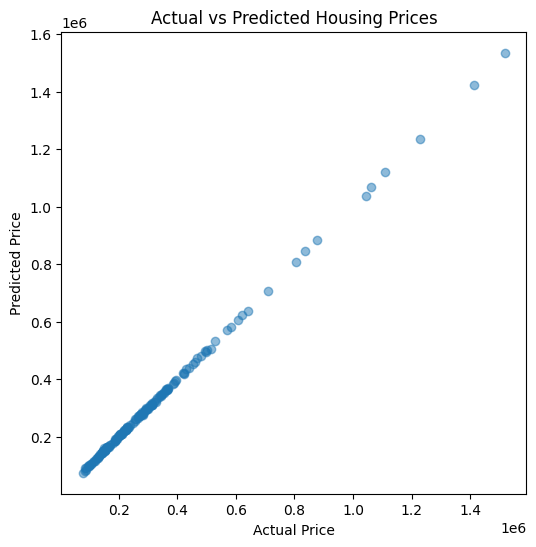

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(sample_df["label"], sample_df["prediction"], alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Housing Prices")
plt.show()